In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


In [2]:
from data_setup import get_data
data = get_data()
orders_fact = data["orders_fact"]
sessions = data["sessions"]
datetable=data["datetable"]
pageviews=data["pageviews"]



2026-03-11 20:46:55.266 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-11 20:46:55.272 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-11 20:46:55.272 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 20:46:56.050 
  command:

    streamlit run c:\Users\91853\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-11 20:46:56.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 20:46:56.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 20:46:56.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 20:46:56.5

In [46]:
sessions["created_at"] = pd.to_datetime(sessions["created_at"])



In [47]:
sessions["Year"] = sessions["created_at"].dt.year
sessions["year_q"] = pd.to_datetime(sessions["created_at"]).dt.to_period("Q")

In [48]:
sessions.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,session_date,...,MonthName,MonthShort,day_name,DayType,channel_type,session_type,First Session Date,days_since_first_session,days_since_first_session_bin,year_q
0,1,2012-03-19 08:04:00,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012-03-19,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:04:00,0,0 days,2012Q1
1,2,2012-03-19 08:16:00,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012-03-19,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:16:00,0,0 days,2012Q1
2,3,2012-03-19 08:26:00,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012-03-19,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:26:00,0,0 days,2012Q1
3,4,2012-03-19 08:37:00,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012-03-19,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:37:00,0,0 days,2012Q1
4,5,2012-03-19 09:00:00,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012-03-19,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 09:00:00,0,0 days,2012Q1


In [49]:
sessions[["created_at","Year","year_q"]].head()

,created_at,Year,year_q
0,2012-03-19 08:04:00,2012,2012Q1
1,2012-03-19 08:16:00,2012,2012Q1
2,2012-03-19 08:26:00,2012,2012Q1
3,2012-03-19 08:37:00,2012,2012Q1
4,2012-03-19 09:00:00,2012,2012Q1


In [50]:
orders_fact.head()

,order_item_id,created_at_x,order_id,product_id,is_primary_item,price_usd,cogs_usd,order_item_date,order_item_time,Year,...,profit,profit_margin,created_at_y,website_session_id,user_id,created_at,product_name,customer_id,avg_order_value,customer_type
0,1,19-03-2012 10:42,1,1,1,49.990002,19.49,2012-03-19,1900-01-01 10:42:46,2012,...,30.500002,0.610122,42:46.0,20,20,00:00.0,The Original Mr. Fuzzy,20,49.990002,One-time Customer
1,2,19-03-2012 19:27,2,1,1,49.990002,19.49,2012-03-19,1900-01-01 19:27:37,2012,...,30.500002,0.610122,27:37.0,104,104,00:00.0,The Original Mr. Fuzzy,104,49.990002,One-time Customer
2,3,20-03-2012 06:44,3,1,1,49.990002,19.49,2012-03-20,1900-01-01 06:44:45,2012,...,30.500002,0.610122,44:45.0,147,147,00:00.0,The Original Mr. Fuzzy,147,49.990002,One-time Customer
3,4,20-03-2012 09:41,4,1,1,49.990002,19.49,2012-03-20,1900-01-01 09:41:45,2012,...,30.500002,0.610122,41:45.0,160,160,00:00.0,The Original Mr. Fuzzy,160,49.990002,One-time Customer
4,5,20-03-2012 11:28,5,1,1,49.990002,19.49,2012-03-20,1900-01-01 11:28:15,2012,...,30.500002,0.610122,28:15.0,177,177,00:00.0,The Original Mr. Fuzzy,177,49.990002,One-time Customer


In [51]:
pageviews.head()

,website_pageview_id,created_at,website_session_id,pageview_url,funnel_step_final
0,1,2012-03-19 08:04:16,1,/home,Landing Page
1,2,2012-03-19 08:16:49,2,/home,Landing Page
2,3,2012-03-19 08:26:55,3,/home,Landing Page
3,4,2012-03-19 08:37:33,4,/home,Landing Page
4,5,2012-03-19 09:00:55,5,/home,Landing Page


In [52]:
page_session=pageviews.merge(sessions,on="website_session_id",how="left")

In [53]:
page_session.head()


,website_pageview_id,created_at_x,website_session_id,pageview_url,funnel_step_final,created_at_y,user_id,is_repeat_session,utm_source,utm_campaign,...,MonthName,MonthShort,day_name,DayType,channel_type,session_type,First Session Date,days_since_first_session,days_since_first_session_bin,year_q
0,1,2012-03-19 08:04:16,1,/home,Landing Page,2012-03-19 08:04:00,1,0,gsearch,nonbrand,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:04:00,0,0 days,2012Q1
1,2,2012-03-19 08:16:49,2,/home,Landing Page,2012-03-19 08:16:00,2,0,gsearch,nonbrand,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:16:00,0,0 days,2012Q1
2,3,2012-03-19 08:26:55,3,/home,Landing Page,2012-03-19 08:26:00,3,0,gsearch,nonbrand,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:26:00,0,0 days,2012Q1
3,4,2012-03-19 08:37:33,4,/home,Landing Page,2012-03-19 08:37:00,4,0,gsearch,nonbrand,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 08:37:00,0,0 days,2012Q1
4,5,2012-03-19 09:00:55,5,/home,Landing Page,2012-03-19 09:00:00,5,0,gsearch,nonbrand,...,March,Mar,Monday,Weekday,Paid Search,New_Session,2012-03-19 09:00:00,0,0 days,2012Q1


In [54]:
#year_month column
page_session["month_year"] = pd.to_datetime(page_session["Year"].astype(str) + "-" + page_session["MonthNumber"].astype(str))

In [55]:
#  Sessions that visited Product Page
product_sessions = page_session[page_session["funnel_step_final"] == "Product Page"]["website_session_id"].unique()
# Sessions that visited any next page after Product
next_page_sessions = page_session[page_session["funnel_step_final"].isin(["Cart", "Billing", "Thank You"])]["website_session_id"].unique()
#  Find sessions that did both
click_sessions = set(product_sessions) & set(next_page_sessions)
# clickthrough rate
ctr = len(click_sessions) / len(product_sessions)

print("Overall Clickthrough Rate:", round(ctr * 100, 2), "%")


Overall Clickthrough Rate: 35.83 %


In [56]:
product_session = (page_session[page_session["funnel_step_final"]=="Product Page"].groupby("year_q")["website_session_id"].nunique().reset_index())

In [57]:
product_session

,year_q,website_session_id
0,2012Q1,743
1,2012Q2,4783
2,2012Q3,8156
3,2012Q4,15786
4,2013Q1,10437
5,2013Q2,13645
6,2013Q3,15646
7,2013Q4,22764
8,2014Q1,23859
9,2014Q2,30017


In [58]:
page_session[page_session["funnel_step_final"]=="Product Page"]["month_year"].max()

Timestamp('2015-01-01 00:00:00')

In [63]:
# first /products pageview per session
products = (page_session[page_session["pageview_url"] == "/products"].sort_values("website_pageview_id").groupby("website_session_id").first().reset_index())
# find pages after /products
next_pages = page_session.merge(products[["website_session_id","website_pageview_id"]],on="website_session_id",suffixes=("","_product"))
next_pages = next_pages[next_pages["website_pageview_id"] > next_pages["website_pageview_id_product"]]
# sessions that clicked through
click_sessions = next_pages["website_session_id"].unique()
# monthly product sessions
products_month = (products.groupby("month_year")["website_session_id"].nunique().reset_index(name="product_sessions"))
# monthly click sessions
click_month = (next_pages.groupby("month_year")["website_session_id"].nunique().reset_index(name="click_sessions"))
# CTR table
ctr_table = products_month.merge(click_month,on="month_year",how="left")
ctr_table["clickthrough_rate"] = (ctr_table["click_sessions"] / ctr_table["product_sessions"])
ctr_table["month_year"] = ctr_table["month_year"].dt.strftime("%Y-%m")
ctr_table


,month_year,product_sessions,click_sessions,clickthrough_rate
0,2012-03,743,530,0.713324
1,2012-04,1447,1029,0.711126
2,2012-05,1585,1136,0.716719
3,2012-06,1751,1246,0.711593
4,2012-07,2019,1439,0.712729
5,2012-08,3011,2197,0.729658
6,2012-09,3126,2258,0.722329
7,2012-10,4030,2948,0.731514
8,2012-11,6744,4850,0.719158
9,2012-12,5012,3619,0.722067


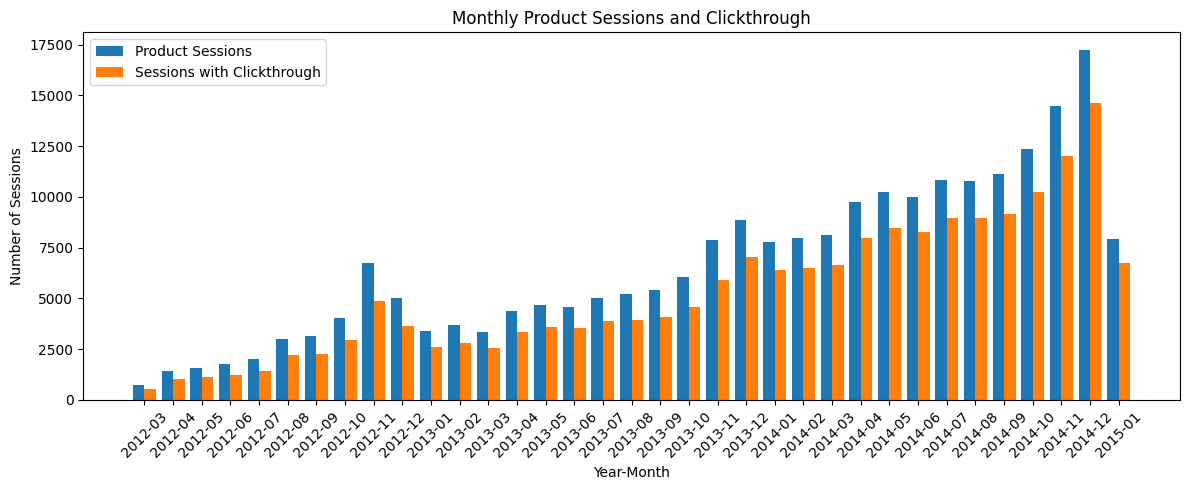

In [66]:
ctr_table["month_year_str"] = ctr_table["month_year"].astype(str)
x = range(len(ctr_table))
plt.figure(figsize=(12,5))
plt.bar(x, ctr_table["product_sessions"], width=0.4, label="Product Sessions")
plt.bar([i + 0.4 for i in x],ctr_table["click_sessions"],width=0.4,label="Sessions with Clickthrough")
plt.xticks([i + 0.2 for i in x],ctr_table["month_year_str"],rotation=45)
plt.title("Monthly Product Sessions and Clickthrough")
plt.xlabel("Year-Month")
plt.ylabel("Number of Sessions")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
ctr_table.to_excel(r"D:\datascience\Analytix_Internship_data_analyst\digital analytics\streamlit\output_file\product_sessions_clickthrough.xlsx",index=False)

In [26]:
pageviews[pageviews["created_at"].dt.year > 2015]

,website_pageview_id,created_at,website_session_id,pageview_url,funnel_step_final


In [27]:
pageviews["pageview_url"] = pageviews["pageview_url"].str.strip()

In [28]:
#billing revenue
billing2_launch = pageviews.loc[pageviews["pageview_url"] == "/billing-2", "created_at"].min()
billing_test_window = pageviews[(pageviews["created_at"] >= "2012-07-10") &(pageviews["created_at"] <= "2012-11-10")]
billing_sessions = (billing_test_window[billing_test_window["pageview_url"].isin(["/billing","/billing-2"])][["website_session_id","pageview_url","created_at"]].drop_duplicates("website_session_id"))
order_revenue = (orders_fact.groupby(["order_id","website_session_id"])["total_net_revenue"].sum().reset_index())
billing_orders = billing_sessions.merge(order_revenue,on="website_session_id",how="left")
billing_orders["test_period"] = np.where(billing_orders["created_at"] < billing2_launch,"before_test_revenue","after_test_revenue")
billing_ab_revenue = (billing_orders.pivot_table(index="pageview_url",columns="test_period",values="total_net_revenue",aggfunc="sum").reset_index())
billing_ab_revenue

test_period,pageview_url,after_test_revenue,before_test_revenue
0,/billing,13997.200195,19496.101562
1,/billing-2,18546.291016,NaN


In [29]:
billing_ab_revenue.to_excel(r"D:\datascience\Analytix_Internship_data_analyst\digital analytics\streamlit\output_file\billing.xlsx",index=False)

In [30]:
billing2_launch = pageviews.loc[pageviews["pageview_url"] == "/billing-2", "created_at"].min()
billing2_launch

Timestamp('2012-09-10 00:13:05')

In [31]:
#conversion rate
billing2_launch = pageviews.loc[pageviews["pageview_url"] == "/billing-2", "created_at"].min()
billing_sessions = (pageviews[(pageviews["created_at"] <= "2012-11-10") & (pageviews["pageview_url"].isin(["/billing","/billing-2"]))][["website_session_id","pageview_url","created_at"]].sort_values("created_at").drop_duplicates("website_session_id"))
order_sessions = orders_fact[["website_session_id"]].drop_duplicates()
billing_conv = billing_sessions.merge(order_sessions,on="website_session_id",how="left",indicator=True)
billing_conv["order_flag"] = (billing_conv["_merge"] == "both").astype(int)
billing_conv["test_period"] = np.where(billing_conv["created_at"] <billing2_launch,"before_test","after_test")
billing_conversion = (billing_conv.groupby(["pageview_url","test_period"]).agg(sessions=("website_session_id","count"),orders=("order_flag","sum")).reset_index())
billing_conversion["conversion_rate_%"] = (billing_conversion["orders"] /billing_conversion["sessions"]) * 100
billing_conversion

,pageview_url,test_period,sessions,orders,conversion_rate_%
0,/billing,after_test,657,300,45.662100
1,/billing,before_test,1954,870,44.524053
2,/billing-2,after_test,654,410,62.691131


In [32]:
billing_conversion[["pageview_url","test_period","sessions","orders"]]

,pageview_url,test_period,sessions,orders
0,/billing,after_test,657,300
1,/billing,before_test,1954,870
2,/billing-2,after_test,654,410


In [68]:
#website performance first 8 months
sessions["mon_year"] = pd.to_datetime(sessions["Year"].astype(str) + "-" + sessions["MonthNumber"].astype(str))
start_date=sessions["created_at"].min()
end_date = start_date + pd.DateOffset(months=7)
sessions_first_8 = sessions[(sessions["created_at"] >= start_date) & (sessions["created_at"] <=end_date)]
session_orders = sessions_first_8.merge(orders_fact[["website_session_id","order_id"]],on="website_session_id",how="left")
sessions_count = (session_orders.groupby("mon_year").agg(sessions=("website_session_id","nunique"),orders=("order_id","nunique")).reset_index())
sessions_count["conversion_rate_%"] = round((sessions_count["orders"] /sessions_count["sessions"]) * 100,2)
sessions_count["mon_year"] = sessions_count["mon_year"].dt.strftime("%Y-%m")
sessions_count

,mon_year,sessions,orders,conversion_rate_%
0,2012-03,1879,60,3.19
1,2012-04,3734,99,2.65
2,2012-05,3736,108,2.89
3,2012-06,3963,140,3.53
4,2012-07,4249,169,3.98
5,2012-08,6097,228,3.74
6,2012-09,6546,287,4.38
7,2012-10,4609,206,4.47


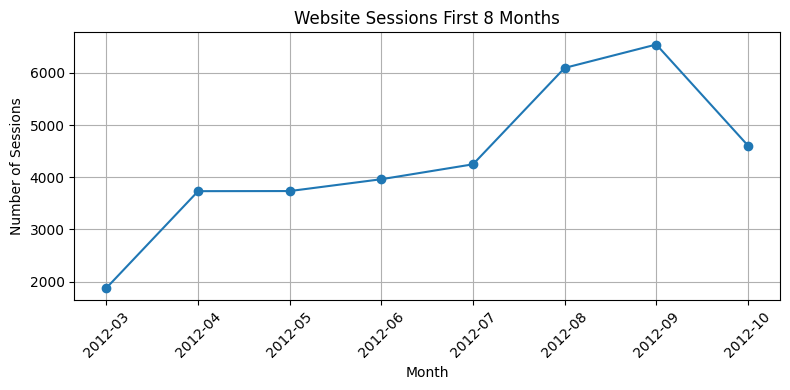

In [69]:
plt.figure(figsize=(8,4))
plt.plot(sessions_count["mon_year"],sessions_count["sessions"],marker="o")
plt.title("Website Sessions First 8 Months")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
sessions_count.to_excel(r"D:\datascience\Analytix_Internship_data_analyst\digital analytics\streamlit\output_file\session_first_8.xlsx",index=False)

In [35]:
#Find first pageview of each session
first_pageviews = (pageviews.sort_values("created_at").groupby("website_session_id").first().reset_index())
# Merge with sessions to get traffic source
first_pageviews = first_pageviews.merge(sessions[["website_session_id","utm_source","utm_campaign"]],on="website_session_id",how="left")
#Filter gsearch nonbrand traffic
first_pageviews = first_pageviews[(first_pageviews["utm_source"] == "gsearch") & (first_pageviews["utm_campaign"] == "nonbrand")]
#Keep only home and lander pages
first_pageviews = first_pageviews[first_pageviews["pageview_url"].isin(["/home","/lander-1"])]
#Test period filter
first_pageviews = first_pageviews[(first_pageviews["created_at"] >= "2012-06-19") &(first_pageviews["created_at"] <= "2012-07-28")]
#Merge orders
orders_flag = orders_fact[["website_session_id"]].drop_duplicates()
test_data = first_pageviews.merge(orders_flag,on="website_session_id",how="left",indicator=True)
test_data["order_flag"] = (test_data["_merge"] == "both").astype(int)
lander_test = (test_data.groupby("pageview_url").agg(sessions=("website_session_id","nunique"),orders=("order_flag","sum")).reset_index())
lander_test["CVR"] = (lander_test["orders"] / lander_test["sessions"]) * 100
lander_test

,pageview_url,sessions,orders,CVR
0,/home,2261,72,3.184432
1,/lander-1,2316,94,4.058722


In [74]:
first_pageviews_after = (pageviews.sort_values("created_at").groupby("website_session_id").first().reset_index())
first_pageviews_after = first_pageviews_after.merge(sessions[["website_session_id","utm_source","utm_campaign"]],on="website_session_id",how="left")
first_pageviews_after = first_pageviews_after[(first_pageviews_after["utm_source"] == "gsearch") & (first_pageviews_after["utm_campaign"] == "nonbrand") & (first_pageviews_after["created_at"] > "2012-07-28")]
sessions_after_test = first_pageviews_after["website_session_id"].nunique()
home_cvr = lander_test.loc[lander_test["pageview_url"]=="/home","CVR"].values[0]
lander_cvr = lander_test.loc[lander_test["pageview_url"]=="/lander-1","CVR"].values[0]
cvr_lift = (lander_cvr - home_cvr) / 100
incremental_orders = sessions_after_test * cvr_lift
avg_order_value = (orders_fact["total_net_revenue"].sum() /orders_fact["order_id"].nunique())


# incremental revenue
incremental_revenue = incremental_orders * avg_order_value
incremental_orders, incremental_revenue

(np.float64(2093.7765600377056), np.float64(120079.40838585018))

In [53]:
#baseline cvr
first_pageviews = (pageviews.sort_values("created_at").groupby("website_session_id").first().reset_index())
first_pageviews = first_pageviews.merge(sessions[["website_session_id","utm_source","utm_campaign"]],on="website_session_id",how="left")
lander_sessions = first_pageviews[(first_pageviews["utm_source"] == "gsearch") & (first_pageviews["utm_campaign"] == "nonbrand") &(first_pageviews["pageview_url"]=="/home")]
baseline = lander_sessions[lander_sessions["created_at"] < "2012-06-19"]
baseline_sessions = baseline["website_session_id"].nunique()
orders_flag = orders_fact[["website_session_id"]].drop_duplicates()
baseline_orders = baseline.merge(orders_flag,on="website_session_id",how="inner")["website_session_id"].nunique()
baseline_cvr = (baseline_orders / baseline_sessions) * 100
baseline_cvr

2.865973588086541

In [54]:
print("Baseline Sessions:", baseline_sessions)
print("Baseline Orders:", baseline_orders)

Baseline Sessions: 10677
Baseline Orders: 306


In [61]:
#test cvr
test_period = first_pageviews[(first_pageviews["utm_source"] == "gsearch") &(first_pageviews["utm_campaign"] == "nonbrand") &(first_pageviews["pageview_url"].isin(["/home","/lander-1"])) &(first_pageviews["created_at"] >= "2012-06-19") &(first_pageviews["created_at"] <= "2012-07-28")]
test_sessions = test_period["website_session_id"].nunique()
test_orders = test_period.merge(orders_flag,on="website_session_id",how="inner")["website_session_id"].nunique()
test_cvr = (test_orders / test_sessions) * 100
test_orders
test_sessions
test_cvr

3.626829801179812

In [68]:
#cvrlift
cvr_diff=(test_cvr-baseline_cvr)/100
cvr_diff

0.00760856213093271

In [70]:
#session_after_test
#incremental_revenue
incre_orders=sessions_after_test*cvr_diff
incre_revenue=incre_orders*avg_order_value
print("incre orders",incre_orders)
print("incre_revenue",incre_revenue)

incre orders 1822.1212848021582
incre_revenue 104499.81
